In [15]:
import pandas as pd
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply({lambda x: ast.literal_eval(x) if pd.notna(x) else(x)})

In [16]:
df_DA_india = df[(df['job_title_short'] == 'Data Analyst') & (df['job_location'] == 'India')].copy()

df_DA_india = df_DA_india.dropna(subset=['salary_year_avg'])

In [17]:
df_DA_india = df_DA_india.explode('job_skills')

df_DA_india[['salary_year_avg','job_skills']]

,salary_year_avg,job_skills
29583,119250.0,sql
29583,119250.0,visio
29583,119250.0,excel
29583,119250.0,jira
29583,119250.0,confluence
180256,64600.0,sql
180256,64600.0,t-sql
180256,64600.0,vba
180256,64600.0,sql server
180256,64600.0,ms access


In [21]:
df_DA_india_group=df_DA_india.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

df_DA_top_pay = df_DA_india_group.sort_values(by='median', ascending=False).head(10)

df_DA_skill = df_DA_india_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False).head(10)

df_DA_skill

,count,median
job_skills,,
flow,2,96603.75
word,3,89118.00
excel,8,82092.75
sql,9,79200.00
tableau,3,79200.00
windows,1,79200.00
python,6,75400.00
oracle,1,75067.50
r,3,71600.00


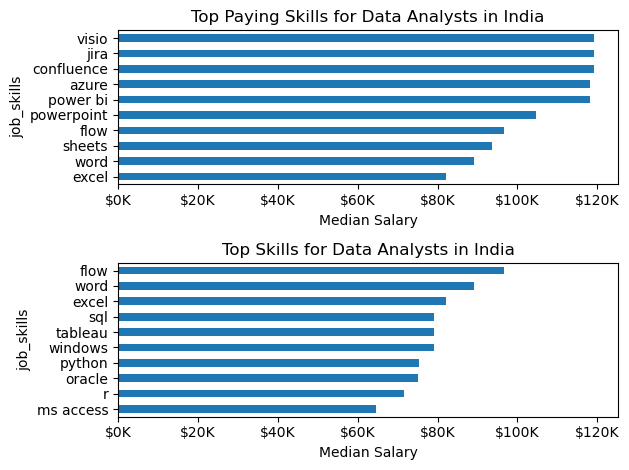

In [35]:
fig, ax = plt.subplots(2,1)

df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top Paying Skills for Data Analysts in India')
ax[0].set_xlabel('Median Salary')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${int(x/1000)}K'))
fig.tight_layout()



df_DA_skill[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top Skills for Data Analysts in India')
ax[1].set_xlabel('Median Salary')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${int(x/1000)}K'))

fig.tight_layout()
